# Proyecto Integrador de Aprendizaje Automático

Para el mercado de autos usados el precio de un vehículo dependen de múltiples factores. Con el uso de técnicas de Machine Learning vamos a construir modelos predictivos capaces de estimar el precio de un vehículo en función de sus características y saber si tendrá alta o baja demanda. 
Por ello, vamos a implementar modelos de regresión y clasificación supervisada, utilizando Ridge y Lasso, así como regresión logística. A través de un flujo completo con Pipeline y ajuste de hiperparámetros con GridSearchCV, se busca garantizar soluciones generalizables.

Esto va a ser de gran ayuda pues para los compradores y vendedores tomar decisiones rápidas y acertadas resultan importantes para evaluar de manera precisa el valor de un automóvil y su potencial. 
Por ello, este proyecto tiene un impacto práctico en tal pues ofrece predicciones útiles para la toma de decisiones estratégicas.


Para ello, iniciamos importando las librerias que necesitamos

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Leemos nuestro dataset sugerido

In [41]:
dataset = pd.read_csv('vehicles.csv', sep=',')

El tamaño de nuestro dataset:

In [42]:
print("Dimensiones:", dataset.shape)

Dimensiones: (426880, 26)


Revisamos las primeras 5 filas del dataset:

In [43]:
dataset.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


Las 5 últimas filas:

In [44]:
dataset.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


Vemos que siguen en orden la información. Ahora vemos la naturaleza de los datos:

In [45]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

Vemos que hay 7 variables numéricas y 19 variables categóricas. Aplicando esta función vemos que puede haber presencia de datos faltantes, por ello vamos a ver en qué variables se están presentando dichos faltantes.

In [46]:
dataset.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [47]:
dataset.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

Nos damos cuenta que en la variable County, que está mal escrita, está llena de datos faltantes, y al no ser relevante en el estudio, es mejor eliminarla. También la variable de tamaño hay más del 70% de nulos y en VIN hay 37% de nulos.
Para el url de la imagen, descripción y fecha de publicación tienen muy pocos nulos, por lo que no implican un peligro en los siguientes pasos para nuestro EDA. Y las variables como id, url, y el url de la región se podrían categorizar como irrelevantes, por lo que se pueden eliminar.

Para variables numéricas como el año y el odómetro hay aprox. un 0.3% a 1% de datos faltantes, por lo que será mejor imputar con la mediana de estas mismas. Para la latitud  y la longitud se presenta un porcentaje de 1.5%, por lo que también se pueden imputar con la mediana.

Para las variables categóricas, como la manufactura, con un 4% de nulos, el modelo, con un 1.2% de nulos, el combustible, con un 0.7% de nulos, el título de estado, con un 2% de nulos, y la transmisión, con un 0.6% de nulos, se deben imputar con la moda. En las variables de condición, con un 41% de nulos se podría, el cilindraje, la conducción y el color de la puntura, o imputarlas con desconocido (unknown), o eliminarlas.

Por ello, al haber presencia de datos faltantes en la mayoría de variables, iniciamos su tratamiento para luego verificar distribución después de imputar para analizar si no se distorsionaron los datos.

In [48]:
total_registros = len(dataset)
faltantes_por_columna = dataset.isnull().sum()
porcentaje_faltantes = (faltantes_por_columna / total_registros) * 100
analisis_faltantes = pd.DataFrame({
    'Valores_Faltantes': faltantes_por_columna,
    'Porcentaje_Faltantes': porcentaje_faltantes
})
print("Análisis de faltantes:")
print(analisis_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))
variables_eliminar_faltantes = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] > 40].index.tolist()
variables_imputar = analisis_faltantes[(analisis_faltantes['Porcentaje_Faltantes'] > 0) & 
                                     (analisis_faltantes['Porcentaje_Faltantes'] <= 40)].index.tolist()
variables_limpias = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] == 0].index.tolist()

print(f"Podemos eliminar esta (s) variables pues tiene un porcentaje aprox. mayor a 40% de faltantes: {len(variables_eliminar_faltantes)} variables")
print(f"Podemos hacer proceso de imputación con esta (s) variables pues tiene un porcentaja aprox. entre 0-40% de faltantes: {len(variables_imputar)} variables")
print(f"Variables limpias pues tienen un porcentaje de 0% de faltantes: {len(variables_limpias)} variables")

Análisis de faltantes:
              Valores_Faltantes  Porcentaje_Faltantes
county                   426880            100.000000
size                     306361             71.767476
cylinders                177678             41.622470
condition                174104             40.785232
VIN                      161042             37.725356
drive                    130567             30.586347
paint_color              130203             30.501078
type                      92858             21.752717
manufacturer              17646              4.133714
title_status               8242              1.930753
lat                        6549              1.534155
long                       6549              1.534155
model                      5277              1.236179
odometer                   4400              1.030735
fuel                       3013              0.705819
transmission               2556              0.598763
year                       1205              0.282281
descr

Con las variables identificadas según su porcentaje de datos faltantes, empezamos con el tratamiento:

Primero, estudiamos las variables que para nuestro estudio pueden ser irrelevantes:

In [49]:
def identificar_variables_irrelevantes(dataset):
    variables_irrelevantes = [
        'id', 'url', 'region_url', 'image_url', 'description',
        'posting_date', 'VIN', 'county', 'lat', 'long'
    ]
    return [col for col in variables_irrelevantes if col in dataset.columns]

variables_irrelevantes = identificar_variables_irrelevantes(dataset)

print("Variables irrelevantes:")
for i, col in enumerate(variables_irrelevantes, 1):
    print(f"{i}. {col}")

Variables irrelevantes:
1. id
2. url
3. region_url
4. image_url
5. description
6. posting_date
7. VIN
8. county
9. lat
10. long


Identificando hasta ahora estas variables, se escogieron por la gran cantidad de datos faltantes que tienen y su relevancia en el estudio, algunas no tienen un sentido dado al estudio de este proyecto. Por lo que procedemos a sus eliminaciones teniendo seguro que tendremos bien nuestra pase limpia y en función al objetivo que estamos buscando:

In [50]:
todas_variables_eliminar = list(set(variables_eliminar_faltantes + variables_irrelevantes))
for i, var in enumerate(todas_variables_eliminar, 1):
    print(f"{i}. {var}")

print(f"\nDimensiones antes de eliminar: {dataset.shape}")
dataset_clean = dataset.drop(columns=todas_variables_eliminar, errors='ignore')

print(f"Dimensiones después de eliminar: {dataset_clean.shape}")

1. size
2. url
3. region_url
4. image_url
5. condition
6. long
7. county
8. id
9. VIN
10. cylinders
11. lat
12. posting_date
13. description

Dimensiones antes de eliminar: (426880, 26)
Dimensiones después de eliminar: (426880, 13)


También se encontró datos que son inválidos en el estudio que pudieron ser por un error de escritura pues habían valores imposibles que, en un contexto real serían exageradamente imposibles, y se encontraron en las variables de año y el precio del vehículo. Por ello vamos a filtrarlos con el rango correcto:

In [51]:
print(f"Registros antes de filtrar: {len(dataset_clean)}")
precios_antes = len(dataset_clean)
dataset_clean = dataset_clean[(dataset_clean['price'] > 500) & (dataset_clean['price'] < 100000)]
precios_despues = len(dataset_clean)
print(f"• Precios válidos: {precios_despues} registros ({precios_antes - precios_despues} eliminados)")
años_antes = len(dataset_clean)
dataset_clean = dataset_clean[(dataset_clean['year'] >= 1980) & (dataset_clean['year'] <= 2022)]
años_despues = len(dataset_clean)
print(f"• Años válidos: {años_despues} registros ({años_antes - años_despues} eliminados)")

print(f"\nRegistros después de filtrar: {len(dataset_clean)}")

Registros antes de filtrar: 426880
• Precios válidos: 383068 registros (43812 eliminados)
• Años válidos: 373973 registros (9095 eliminados)

Registros después de filtrar: 373973


Con estas variables eliminadas, re-analizamos nuestra base:

In [52]:
faltantes_despues_limpieza = dataset_clean.isnull().sum()
porcentaje_faltantes_despues = (faltantes_despues_limpieza / len(dataset_clean)) * 100

analisis_despues = pd.DataFrame({
    'Valores_Faltantes': faltantes_despues_limpieza,
    'Porcentaje_Faltantes': porcentaje_faltantes_despues
})

variables_con_faltantes = analisis_despues[analisis_despues['Valores_Faltantes'] > 0]
print("Después de la limpieza:")
print(variables_con_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))

Después de la limpieza:
              Valores_Faltantes  Porcentaje_Faltantes
drive                    112893             30.187473
paint_color              107465             28.736032
type                      78700             21.044300
manufacturer              12428              3.323235
title_status               6675              1.784888
model                      3623              0.968787
fuel                       2317              0.619563
odometer                   2032              0.543355
transmission               1744              0.466344


Vemos ahora un porcentaje que no afecta la continuidad de nuestro estudio. Ahora nos vamos a identificación de variables para imputar de acuerdo a su naturaleza

In [53]:
variables_a_imputar = variables_con_faltantes.index.tolist()
numeric_features = []
categorical_features = []
for col in variables_a_imputar:
    if dataset_clean[col].dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Variables numéricas a imputar con mediana:")
for var in numeric_features:
    porcentaje = analisis_despues.loc[var, 'Porcentaje_Faltantes']
    print(f"• {var}: {porcentaje:.1f}% faltantes")

print("Variables categóricas a imputar con moda:")
for var in categorical_features:
    porcentaje = analisis_despues.loc[var, 'Porcentaje_Faltantes']
    print(f"• {var}: {porcentaje:.1f}% faltantes")

Variables numéricas a imputar con mediana:
• odometer: 0.5% faltantes
Variables categóricas a imputar con moda:
• manufacturer: 3.3% faltantes
• model: 1.0% faltantes
• fuel: 0.6% faltantes
• title_status: 1.8% faltantes
• transmission: 0.5% faltantes
• drive: 30.2% faltantes
• type: 21.0% faltantes
• paint_color: 28.7% faltantes


Ahora las imputamos de acuerdo a lo que requieren

In [54]:
print("Imputando de variables numéricas con la mediana:")
if numeric_features:
    numeric_imputer = SimpleImputer(strategy='median')
    dataset_clean[numeric_features] = numeric_imputer.fit_transform(dataset_clean[numeric_features])
    print(f"Imputadas: {', '.join(numeric_features)}")

print("Imputando variables categóricas con la moda:")
if categorical_features:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    dataset_clean[categorical_features] = categorical_imputer.fit_transform(dataset_clean[categorical_features])
    print(f"Imputadas: {', '.join(categorical_features)}")
faltantes_finales = dataset_clean.isnull().sum().sum()
print(f"Valores faltantes restantes: {faltantes_finales}")

Imputando de variables numéricas con la mediana:
Imputadas: odometer
Imputando variables categóricas con la moda:
Imputadas: manufacturer, model, fuel, title_status, transmission, drive, type, paint_color
Valores faltantes restantes: 0


Creamos la variable HighDemand:

In [55]:
dataset_clean['HighDemand'] = (dataset_clean['price'] > dataset_clean['price'].median()).astype(int)
print("Distribución de valores:")
print(dataset_clean['HighDemand'].value_counts())
print(f"Porcentaje de alta demanda: {dataset_clean['HighDemand'].mean()*100:.1f}%")

Distribución de valores:
HighDemand
0    187140
1    186833
Name: count, dtype: int64
Porcentaje de alta demanda: 50.0%


Re-identificamos las variables categóricas para codificarlas:

In [56]:
categorical_features_to_encode = []
for col in dataset_clean.columns:
    if dataset_clean[col].dtype == 'object' and col not in ['price', 'HighDemand']:
        categorical_features_to_encode.append(col)

print("Variables categóricas:")
for i, col in enumerate(categorical_features_to_encode, 1):
    n_categories = dataset_clean[col].nunique()
    print(f"{i}. {col} ({n_categories} categorías)")

Variables categóricas:
1. region (404 categorías)
2. manufacturer (42 categorías)
3. model (25358 categorías)
4. fuel (5 categorías)
5. title_status (6 categorías)
6. transmission (3 categorías)
7. drive (3 categorías)
8. type (13 categorías)
9. paint_color (12 categorías)
10. state (51 categorías)


Vemos cómo quedan:

In [57]:
print(f"Dimensión: {dataset_clean.shape}")
print(f"Rango de precios: ${dataset_clean['price'].min():,} - ${dataset_clean['price'].max():,}")
print(f"Años: {int(dataset_clean['year'].min())} - {int(dataset_clean['year'].max())}")
print(f"HighDemand: {dataset_clean['HighDemand'].value_counts().to_dict()}")
print(f"Variables categóricas para encoding: {len(categorical_features_to_encode)}")

Dimensión: (373973, 14)
Rango de precios: $501 - $99,999
Años: 1980 - 2022
HighDemand: {0: 187140, 1: 186833}
Variables categóricas para encoding: 10


Con esta base trata para datos faltantes, hacemos un pequeño chequeo de sus características y vemos las distribuciones de nuestros datos.

In [58]:
dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373973 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        373973 non-null  object 
 1   price         373973 non-null  int64  
 2   year          373973 non-null  float64
 3   manufacturer  373973 non-null  object 
 4   model         373973 non-null  object 
 5   fuel          373973 non-null  object 
 6   odometer      373973 non-null  float64
 7   title_status  373973 non-null  object 
 8   transmission  373973 non-null  object 
 9   drive         373973 non-null  object 
 10  type          373973 non-null  object 
 11  paint_color   373973 non-null  object 
 12  state         373973 non-null  object 
 13  HighDemand    373973 non-null  int32  
dtypes: float64(2), int32(1), int64(1), object(10)
memory usage: 41.4+ MB


In [59]:
dataset_clean.describe()

,price,year,odometer,HighDemand
count,373973.000000,373973.000000,3.739730e+05,373973.000000
mean,19164.113075,2011.986020,9.748151e+04,0.499590
std,14277.339280,6.404836,1.440029e+05,0.500001
min,501.000000,1980.000000,0.000000e+00,0.000000
25%,7900.000000,2008.000000,3.950000e+04,0.000000
50%,15950.000000,2013.000000,8.900000e+04,0.000000
75%,27990.000000,2017.000000,1.370000e+05,1.000000
max,99999.000000,2022.000000,1.000000e+07,1.000000


Distribución de las variables numéricas:


Distribución de variables numéricas:


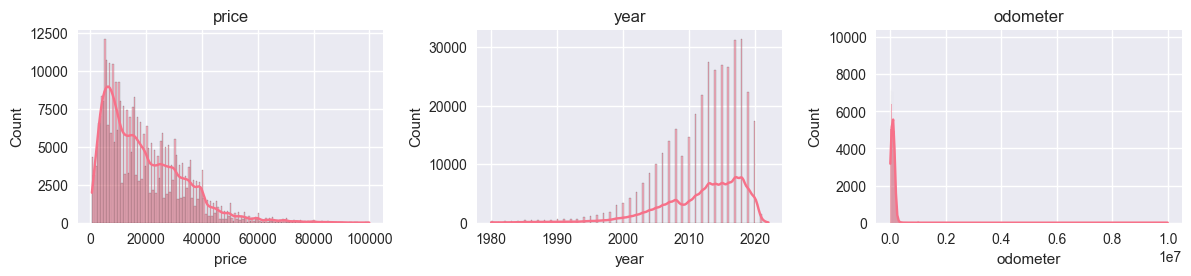

In [60]:
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns.tolist() 
print("\nDistribución de variables numéricas:")
chunk_size = 30
for j in range(0, len(numeric_cols), chunk_size):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(numeric_cols[j:j+chunk_size]):
        plt.subplot(6, 5, i+1)
        sns.histplot(dataset_clean[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

Número de columnas numéricas: 3
Columnas numéricas: ['price', 'year', 'odometer']


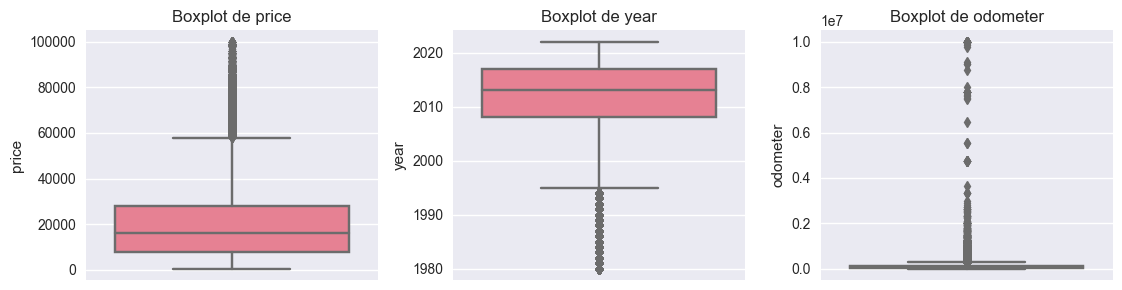

In [61]:
def plot_outliers(dataset_clean, columns):
    n_cols = len(columns)
    n_rows = (n_cols + 3) // 4  
    plt.figure(figsize=(15, 3 * n_rows))
    
    for i, col in enumerate(columns):
        plt.subplot(n_rows, 4, i+1)
        sns.boxplot(y=dataset_clean[col])
        plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Número de columnas numéricas: {len(numeric_cols)}")
print("Columnas numéricas:", list(numeric_cols))
plot_outliers(dataset_clean, numeric_cols)

In [62]:
from scipy.stats import kstest
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns
results = []

for col in numeric_cols:
    data = dataset_clean[col].dropna()  
    if len(data) > 0:  
        mean, std = data.mean(), data.std()
        ks_stat, p_value = kstest(data, 'norm', args=(mean, std))
        
        results.append({
            'Variable': col,
            'N muestras': len(data),
            'KS Statistic': ks_stat,
            'p-value': p_value,
            'Normal (α=0.05)': p_value > 0.05
        })
results_df = pd.DataFrame(results)
print("\n=== Resultados KS (Datos Originales, sin Imputación) ===")
print(results_df.to_string(index=False))
non_normal_vars = results_df[results_df['Normal (α=0.05)'] == False]['Variable'].tolist()
print("\nVariables NO normales (p < 0.05):", non_normal_vars)


=== Resultados KS (Datos Originales, sin Imputación) ===
Variable  N muestras  KS Statistic  p-value  Normal (α=0.05)
   price      373973      0.102130      0.0            False
    year      373973      0.127249      0.0            False
odometer      373973      0.249222      0.0            False

Variables NO normales (p < 0.05): ['price', 'year', 'odometer']


Al haber presencia de datos atípicos pues no tienen una distribución normal, hacemo tratamiento de estos con RobustScaler:

Estadísticas con RobustScaler:
            year   odometer      price
count  373973.00  373973.00  373973.00
mean       -0.11       0.09       0.16
std         0.71       1.48       0.71
min        -3.67      -0.91      -0.77
25%        -0.56      -0.51      -0.40
50%         0.00       0.00       0.00
75%         0.44       0.49       0.60
max         1.00     101.65       4.18


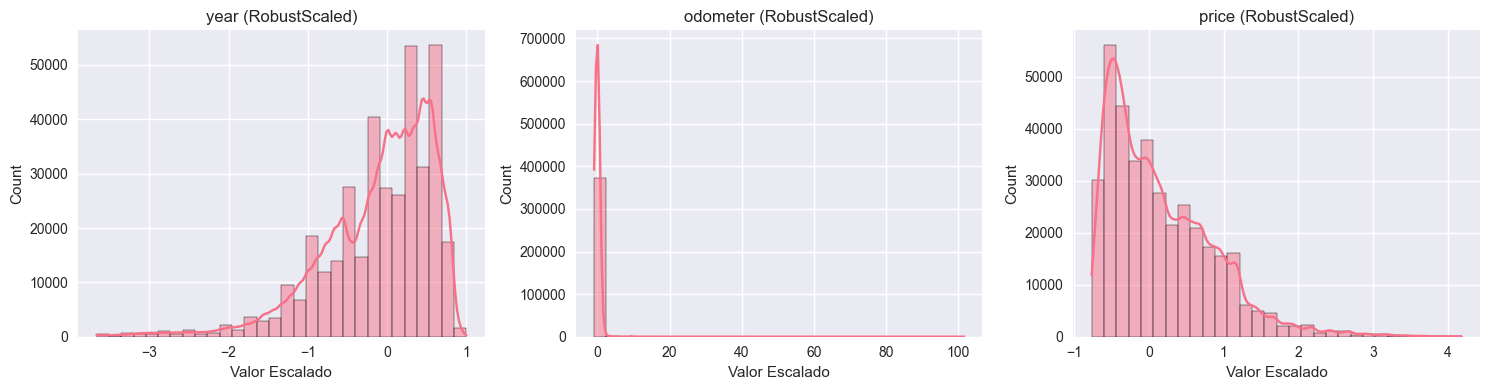

In [63]:
from sklearn.preprocessing import RobustScaler
numeric_features = ['year', 'odometer', 'price']

robust_scaler = RobustScaler()
dataset_robust = dataset_clean.copy()
dataset_robust[numeric_features] = robust_scaler.fit_transform(dataset_clean[numeric_features])

print("Estadísticas con RobustScaler:")
print(dataset_robust[numeric_features].describe().round(2))
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(dataset_robust[col], bins=30, kde=True)
    plt.title(f'{col} (RobustScaled)')
    plt.xlabel('Valor Escalado')

plt.tight_layout()
plt.show()

Al ser los datos de nuestro dataset no normales, vamos a analizar cuales variables tienen una diferencia significativas entre sus grupos.

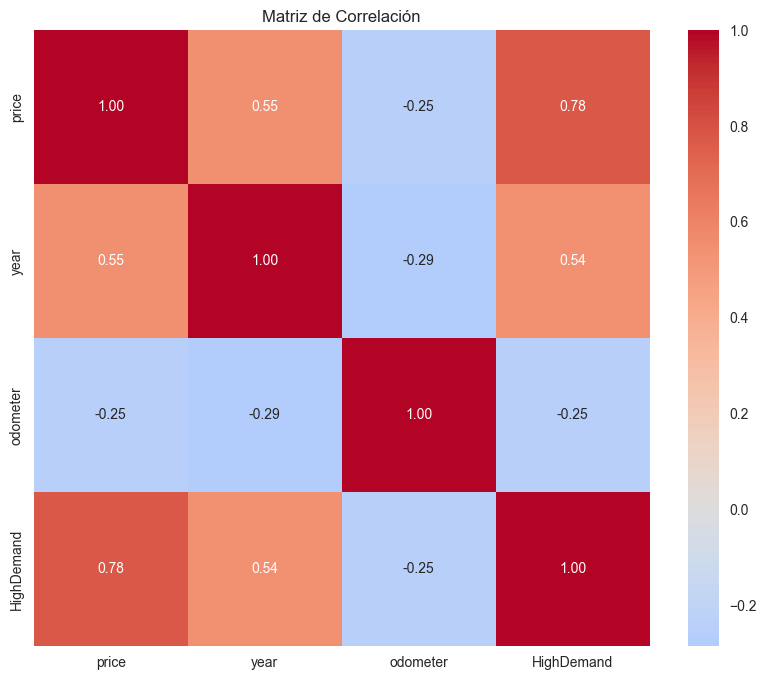

In [64]:
numeric_vars = ['price', 'year', 'odometer', 'HighDemand']
correlation_matrix = dataset_clean[numeric_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def analisis_vif_conciso(df, target_name):
    X = df.drop(columns=[target_name]).select_dtypes(include=[np.number])
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_df = vif_df.sort_values('VIF', ascending=False)
    vif_df["Estado"] = vif_df["VIF"].apply(lambda x: 
        "Normal" if x < 5 else "Moderado" if x < 10 else "Alto")
    
    return vif_df

print("Análisis para regresión con la variable precio")
print("-" * 40)
vif_regresion = analisis_vif_conciso(dataset_clean, "price")
print(vif_regresion.to_string(index=False))
print(f"Total variables: {len(vif_regresion)}")
 
print("Análisis para clasificación con la variable HighDemand")
print("-" * 40)
vif_clasificacion = analisis_vif_conciso(dataset_clean, "HighDemand")
print(vif_clasificacion.to_string(index=False))
print(f"Total variables: {len(vif_clasificacion)}")

Análisis para regresión con la variable precio
----------------------------------------
  Variable      VIF Estado
      year 2.918347 Normal
HighDemand 2.137987 Normal
  odometer 1.552845 Normal
Total variables: 3
Análisis para clasificación con la variable HighDemand
----------------------------------------
Variable      VIF Estado
    year 3.898548 Normal
   price 2.998180 Normal
odometer 1.551248 Normal
Total variables: 3


Análisis univariado

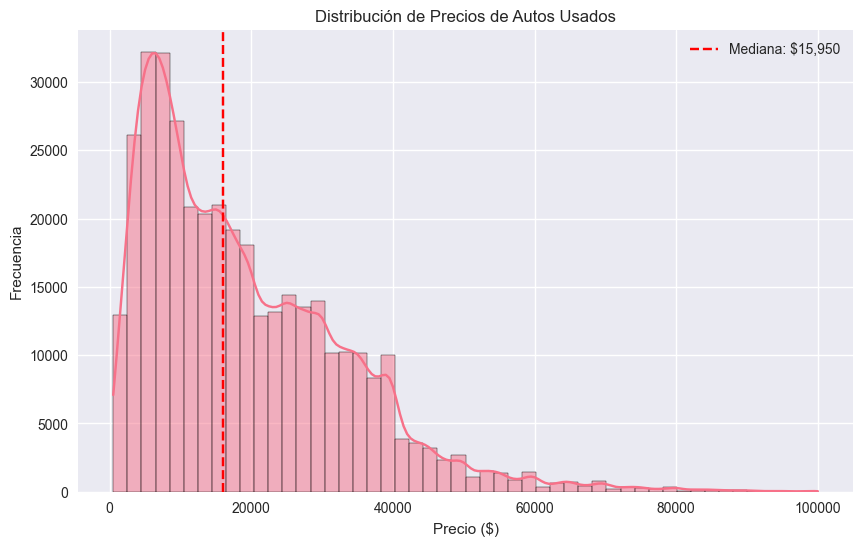

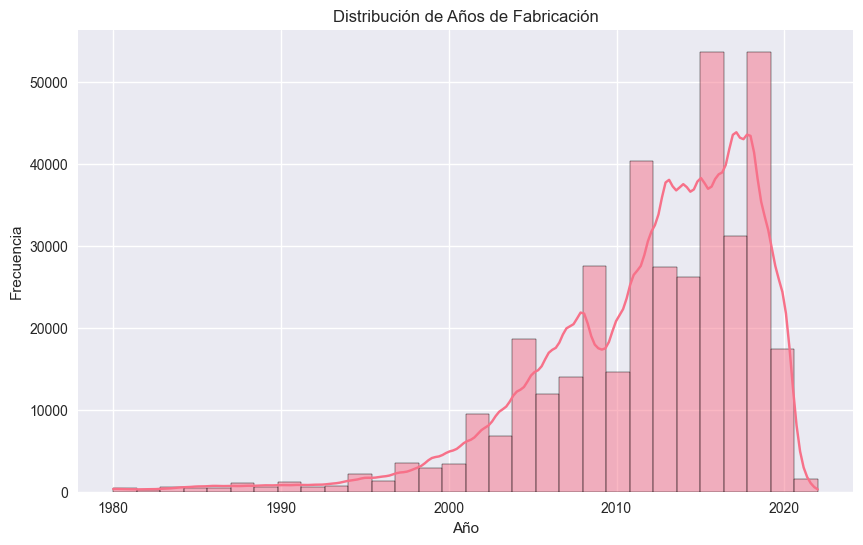

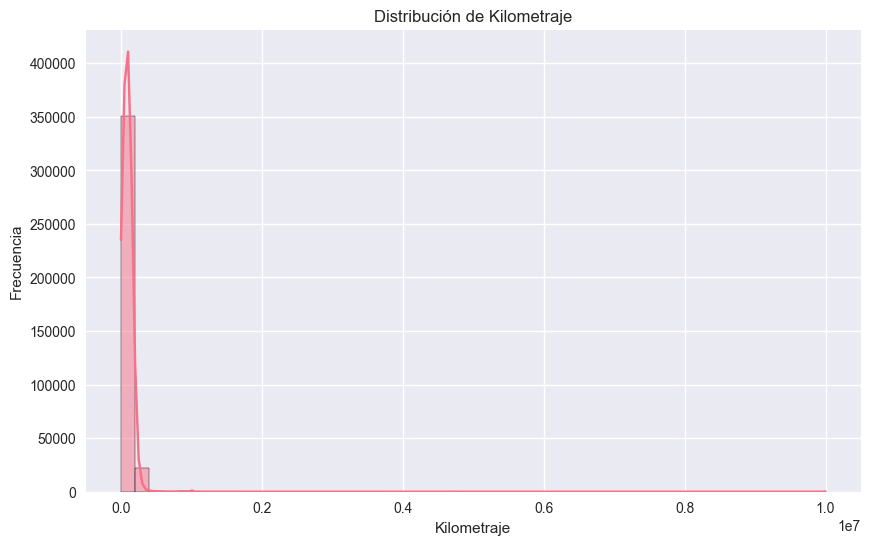

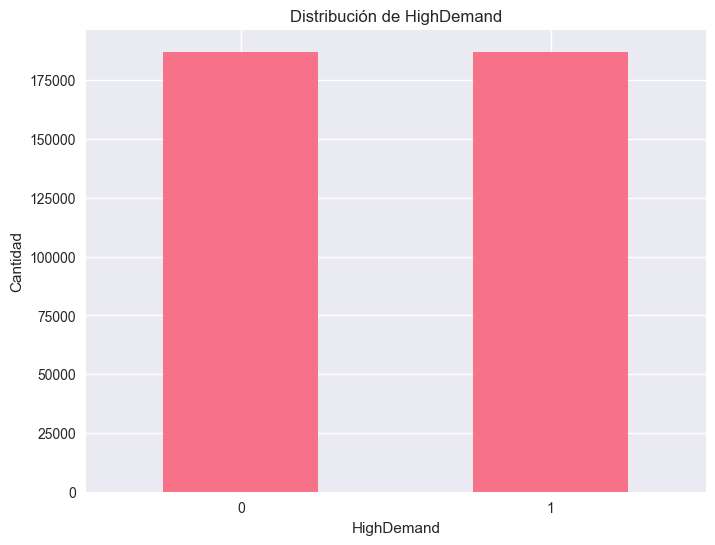

In [66]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl") 
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['price'], bins=50, kde=True)
plt.title('Distribución de Precios de Autos Usados')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.axvline(dataset_clean['price'].median(), color='red', linestyle='--', 
            label=f'Mediana: ${dataset_clean["price"].median():,.0f}')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['year'], bins=30, kde=True)
plt.title('Distribución de Años de Fabricación')
plt.xlabel('Año')
plt.ylabel('Frecuencia')
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['odometer'], bins=50, kde=True)
plt.title('Distribución de Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Frecuencia')
plt.show()
plt.figure(figsize=(8, 6))
dataset_clean['HighDemand'].value_counts().plot(kind='bar')
plt.title('Distribución de HighDemand')
plt.xlabel('HighDemand')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

Análisis bivariado

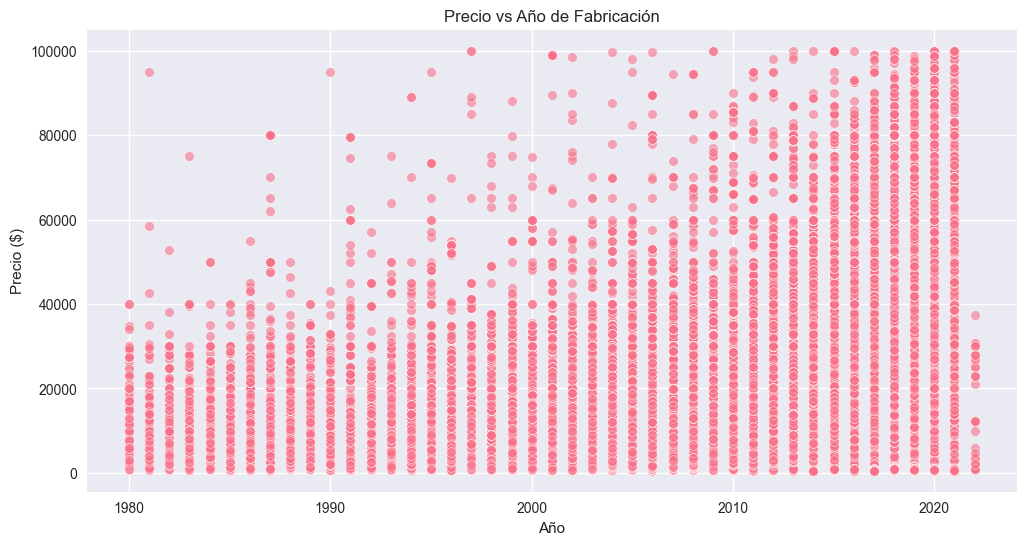

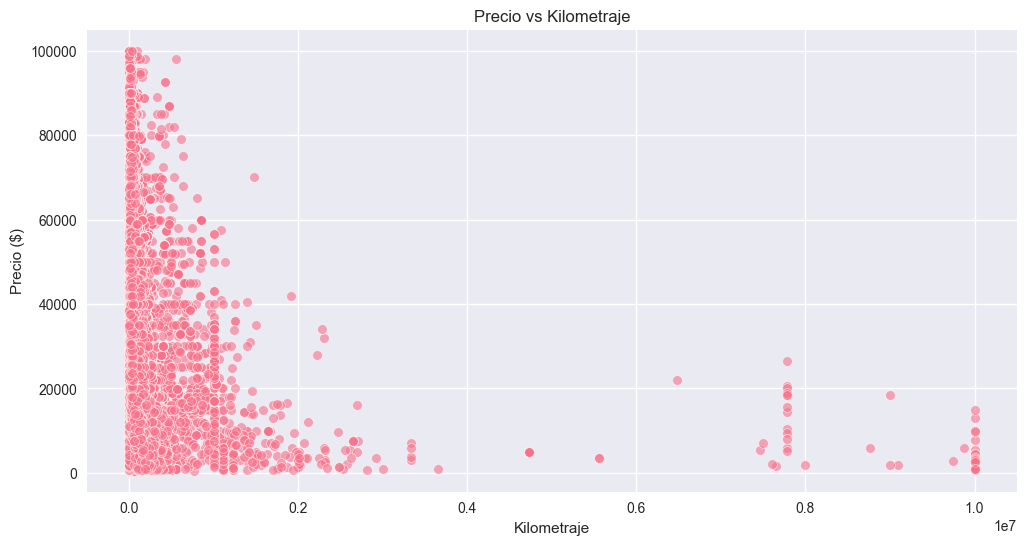

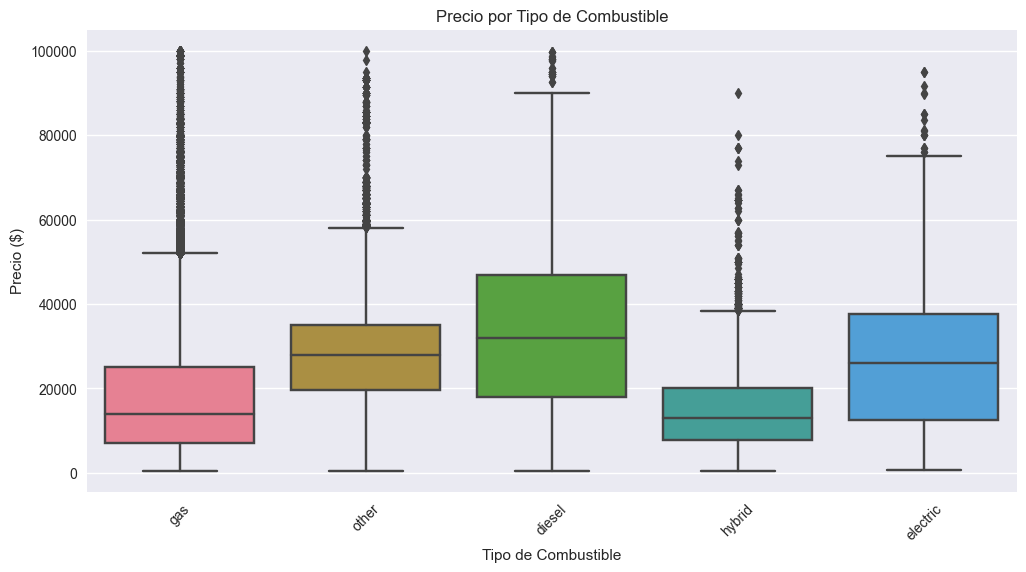

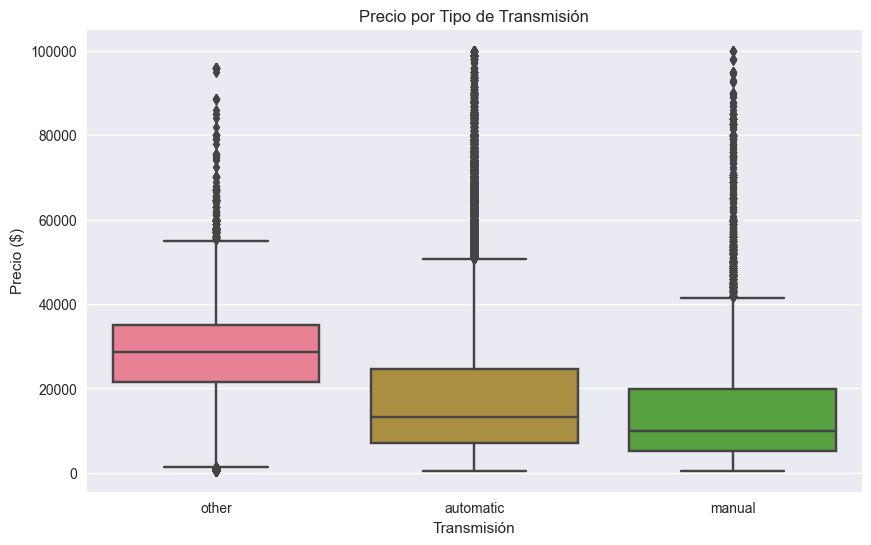

In [67]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset_clean, x='year', y='price', alpha=0.6)
plt.title('Precio vs Año de Fabricación')
plt.xlabel('Año')
plt.ylabel('Precio ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset_clean, x='odometer', y='price', alpha=0.6)
plt.title('Precio vs Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Precio ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=dataset_clean, x='fuel', y='price')
plt.title('Precio por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset_clean, x='transmission', y='price')
plt.title('Precio por Tipo de Transmisión')
plt.xlabel('Transmisión')
plt.ylabel('Precio ($)')
plt.show()

Análisis de tops

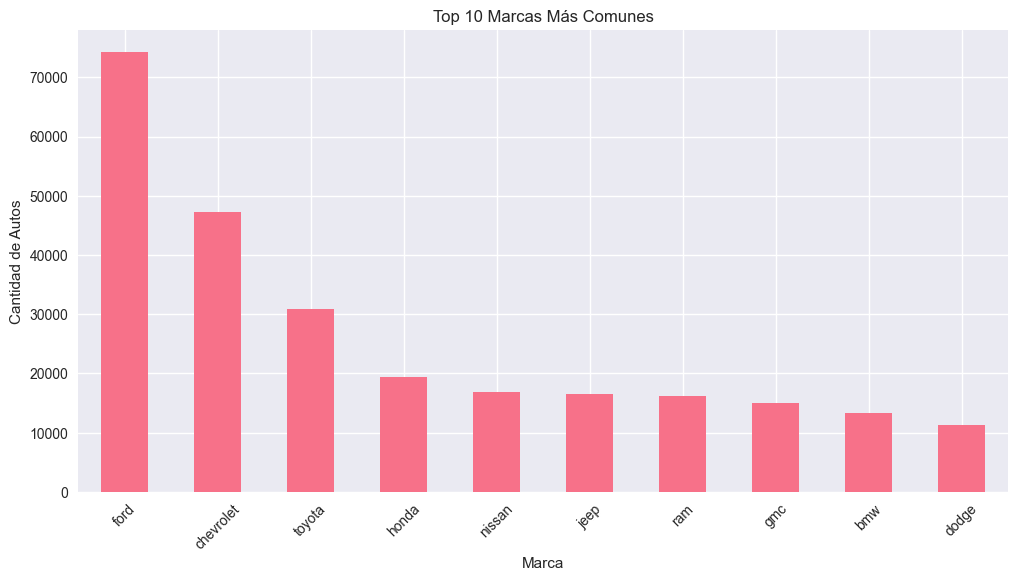

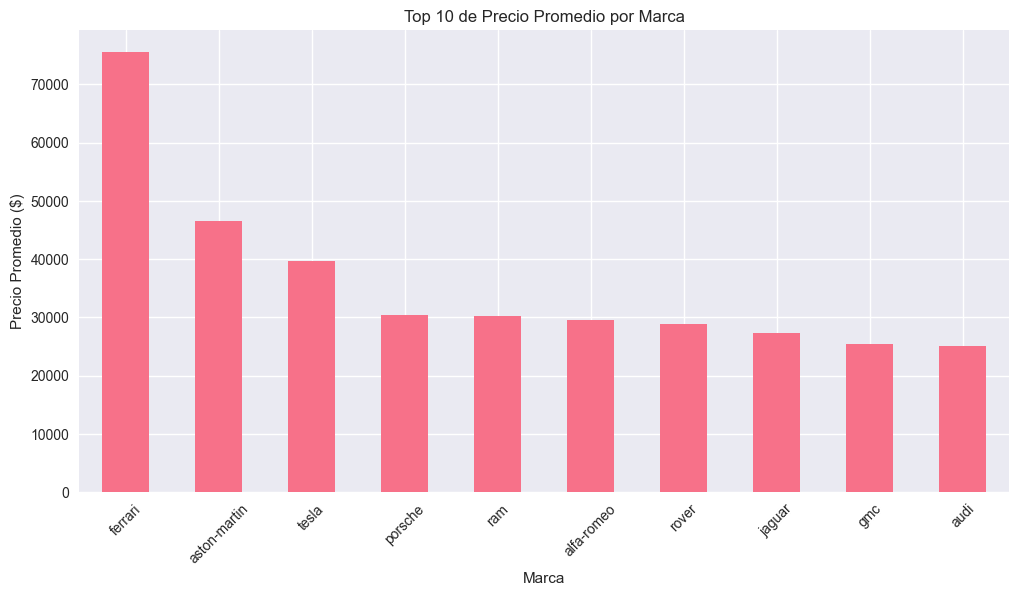

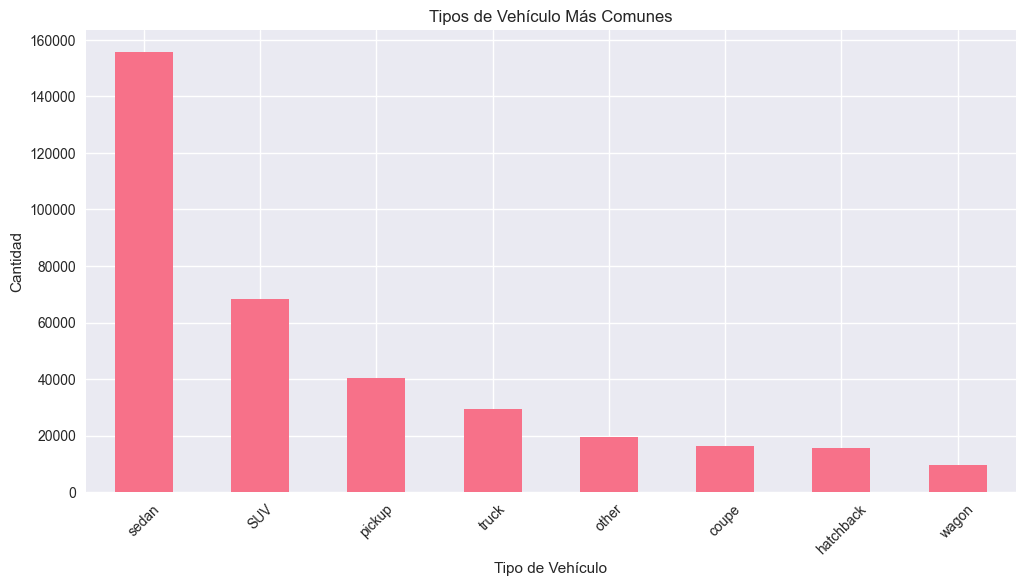

In [68]:
plt.figure(figsize=(12, 6))
top_10_brands = dataset_clean['manufacturer'].value_counts().head(10)
top_10_brands.plot(kind='bar')
plt.title('Top 10 Marcas Más Comunes')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Autos')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
price_by_brand = dataset_clean.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(10)
price_by_brand.plot(kind='bar')
plt.title('Top 10 de Precio Promedio por Marca')
plt.xlabel('Marca')
plt.ylabel('Precio Promedio ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
dataset_clean['type'].value_counts().head(8).plot(kind='bar')
plt.title('Tipos de Vehículo Más Comunes')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()